# Logistic Regression and Feature Scaling Across Healthcare Datasets

This notebook applies logistic regression with feature scaling across three healthcare-related datasets: diabetes, life expectancy, and SUPPORT2. The workflow includes dataset loading, basic inspection, missing-value review, train-test splitting, standardization, model fitting, class-weight comparison, classification reports, and confusion-matrix visualization.

This notebook is included in the modeling folder because the main focus is predictive modeling, feature scaling, and model-performance comparison rather than exploratory data analysis.


In [1]:
import pandas as pd

## Diabetes Dataset Modeling

This section applies logistic regression to the diabetes health indicators dataset. The model is evaluated with and without balanced class weights to compare overall accuracy against performance on underrepresented diabetes-risk classes.


In [2]:
df_diabetes = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

In [3]:
print("Diabetes:", df_diabetes.shape)

Diabetes: (253680, 22)


In [4]:
print("Diabetes:", df_diabetes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [5]:
print("Diabetes:") 
df_diabetes.describe()

Diabetes:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [6]:
#Check for empty cells for diabetes dataset

print(df_diabetes.isnull().sum())

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# Features and Target
X = df_diabetes.drop(columns=['Diabetes_012'])
y = df_diabetes['Diabetes_012']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build pipeline: Scaling and Logistic Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42))
])

#Fit pipeline
pipeline.fit(X_train, y_train)

#Predictions for y
y_pred = pipeline.predict(X_test)

#Evaluation for the results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8454746136865342

Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42741
         1.0       0.00      0.00      0.00       926
         2.0       0.51      0.17      0.26      7069

    accuracy                           0.85     50736
   macro avg       0.46      0.38      0.39     50736
weighted avg       0.80      0.85      0.81     50736



Accuracy (balanced): 0.6457544938505203

Classification Report (balanced):
               precision    recall  f1-score   support

         0.0       0.95      0.66      0.78     42741
         1.0       0.03      0.33      0.06       926
         2.0       0.35      0.58      0.44      7069

    accuracy                           0.65     50736
   macro avg       0.45      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736



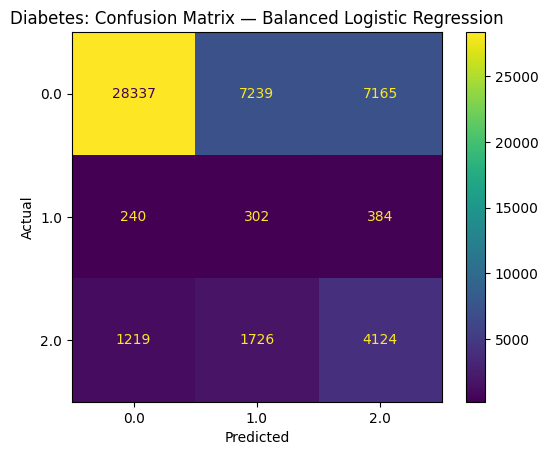

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Features & target
X = df_diabetes.drop(columns=['Diabetes_012'])
y = df_diabetes['Diabetes_012']

#Train and test split: stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Scale features: fit on train, and also transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#Logistic Regression with class imbalance handling done
log_reg_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)
log_reg_balanced.fit(X_train_scaled, y_train)

#Predict & evaluate 
y_pred_balanced = log_reg_balanced.predict(X_test_scaled)

print("Accuracy (balanced):", accuracy_score(y_test, y_pred_balanced))
print("\nClassification Report (balanced):\n",
      classification_report(y_test, y_pred_balanced))

#Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced)
plt.title("Diabetes: Confusion Matrix — Balanced Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Diabetes Modeling Summary

The unbalanced logistic regression model achieved higher overall accuracy, but it performed poorly on the minority diabetes and prediabetes classes. Using balanced class weights reduced overall accuracy but improved recall for underrepresented classes, which is important in healthcare screening tasks where missed risk cases matter.


## Life Expectancy Dataset Modeling

This section applies logistic regression with feature scaling to the life expectancy dataset after converting the outcome into a classification target. The goal is to compare baseline and balanced logistic regression performance on a healthcare outcome variable.


In [9]:
df_life_expectancy = pd.read_csv("Life Expectancy Data.csv")

In [10]:
df_life_expectancy.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [11]:
print("Life Expectancy:", df_life_expectancy.shape)

Life Expectancy: (2938, 22)


In [12]:
print("Life Expectancy:", df_life_expectancy.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [13]:
print("Life Expectancy")
df_life_expectancy.describe()

Life Expectancy


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [14]:
import pandas as pd

# Load dataset
df_life_expectancy = pd.read_csv("Life Expectancy Data.csv")

# Check for missing values
print("Missing values per column:\n")
print(df_life_expectancy.isnull().sum())

#total missing values
print("\nTotal missing values:", df_life_expectancy.isnull().sum().sum())

Missing values per column:

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

Total missing values: 2563


Baseline Accuracy: 0.9013605442176871

Baseline Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89       260
           1       0.90      0.93      0.91       328

    accuracy                           0.90       588
   macro avg       0.90      0.90      0.90       588
weighted avg       0.90      0.90      0.90       588



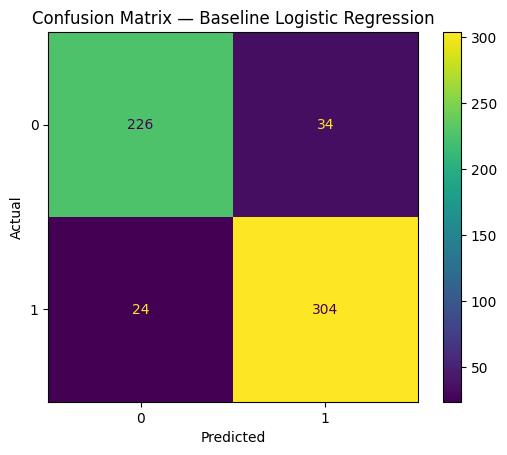

Balanced Accuracy: 0.8962585034013606

Balanced Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.88       260
           1       0.90      0.91      0.91       328

    accuracy                           0.90       588
   macro avg       0.90      0.89      0.89       588
weighted avg       0.90      0.90      0.90       588



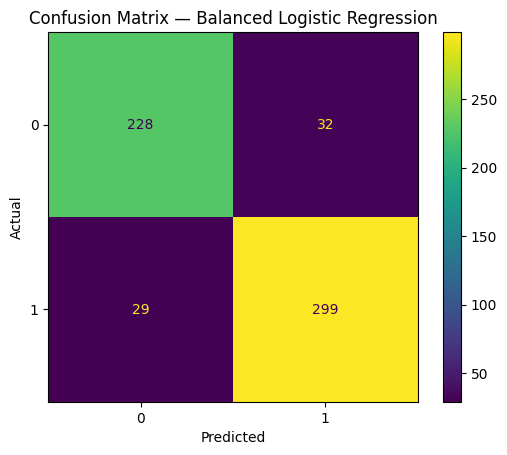

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Clean up column names
df_life_expectancy.columns = df_life_expectancy.columns.str.strip()

#Impute missing numeric cells with median value
df_life_expectancy = df_life_expectancy.fillna(df_life_expectancy.median(numeric_only=True))

#Encode categorical
if 'Status' in df_life_expectancy.columns:
    le = LabelEncoder()
    df_life_expectancy['Status'] = le.fit_transform(df_life_expectancy['Status'])  # Developing/Developed: 0/1

if 'Country' in df_life_expectancy.columns:
    df_life_expectancy = df_life_expectancy.drop(columns=['Country'])

# Create a binary target from life expectancy
threshold = 70  
df_life_expectancy['High_Life_Expectancy'] = (df_life_expectancy['Life expectancy'] >= threshold).astype(int)

#Features/target and split
X = df_life_expectancy.drop(columns=['High_Life_Expectancy', 'Life expectancy'])
y = df_life_expectancy['High_Life_Expectancy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print("\nBaseline Classification Report:\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Logistic Regression with class_weight balanced
log_reg_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_reg_balanced.fit(X_train_scaled, y_train)
y_pred_bal = log_reg_balanced.predict(X_test_scaled)

print("Balanced Accuracy:", accuracy_score(y_test, y_pred_bal))
print("\nBalanced Classification Report:\n", classification_report(y_test, y_pred_bal))

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bal)
plt.title("Confusion Matrix — Balanced Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Life Expectancy Modeling Summary

The logistic regression model performed well after preprocessing and feature scaling, with approximately 90% accuracy. Balanced class weighting produced similar performance, suggesting that class imbalance was less severe for this classification setup than in the diabetes dataset.


## SUPPORT2 Dataset Modeling

This section applies logistic regression with feature scaling to the SUPPORT2 dataset. The workflow includes missing-value handling, target preparation, model fitting, and comparison of standard versus balanced class weighting.


In [16]:
df_support = pd.read_csv("support2.csv")

In [17]:
print("Support:", df_support.shape)

Support: (9105, 45)


In [18]:
print("Support", df_support.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 45 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       9105 non-null   float64
 1   sex       9105 non-null   object 
 2   dzgroup   9105 non-null   object 
 3   dzclass   9105 non-null   object 
 4   num.co    9105 non-null   int64  
 5   edu       7471 non-null   float64
 6   income    6123 non-null   object 
 7   scoma     9104 non-null   float64
 8   charges   8933 non-null   float64
 9   totcst    8217 non-null   float64
 10  totmcst   5630 non-null   float64
 11  avtisst   9023 non-null   float64
 12  race      9063 non-null   object 
 13  sps       9104 non-null   float64
 14  aps       9104 non-null   float64
 15  surv2m    9104 non-null   float64
 16  surv6m    9104 non-null   float64
 17  hday      9105 non-null   int64  
 18  diabetes  9105 non-null   int64  
 19  dementia  9105 non-null   int64  
 20  ca        9105 non-null   obje

In [19]:
print("Support")
df_support.describe()

Support


,age,num.co,edu,scoma,charges,totcst,totmcst,avtisst,sps,aps,...,sod,ph,glucose,bun,urine,adlp,adls,adlsc,death,hospdead
count,9105.000000,9105.000000,7471.000000,9104.000000,8.933000e+03,8217.000000,5630.000000,9023.000000,9104.000000,9104.000000,...,9104.000000,6821.000000,4605.000000,4753.000000,4243.000000,3464.000000,6238.000000,9105.000000,9105.000000,9105.000000
mean,62.650823,1.868644,11.747691,12.058546,5.999579e+04,30825.867768,28828.877838,22.610928,25.525872,37.597979,...,137.568541,7.415364,159.873398,32.349463,2191.546047,1.157910,1.637384,1.888272,0.681054,0.259198
std,15.593710,1.344409,3.447743,24.636694,1.026488e+05,45780.820986,43604.261932,13.233248,9.899377,19.903852,...,6.029326,0.080563,88.391541,26.792288,1455.245777,1.739672,2.231358,2.003763,0.466094,0.438219
min,18.041990,0.000000,0.000000,0.000000,1.169000e+03,0.000000,-102.719970,1.000000,0.199982,0.000000,...,110.000000,6.829102,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,52.797000,1.000000,10.000000,0.000000,9.740000e+03,5929.566400,5177.404300,12.000000,19.000000,23.000000,...,134.000000,7.379883,103.000000,14.000000,1165.500000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,64.856990,2.000000,12.000000,0.000000,2.502400e+04,14452.734400,13223.500000,19.500000,23.898438,34.000000,...,137.000000,7.419922,135.000000,23.000000,1968.000000,0.000000,1.000000,1.000000,1.000000,0.000000
75%,73.998960,3.000000,14.000000,9.000000,6.459800e+04,36087.937500,34223.601600,31.666656,30.199219,49.000000,...,141.000000,7.469727,188.000000,42.000000,3000.000000,2.000000,3.000000,3.000000,1.000000,1.000000
max,101.847960,9.000000,31.000000,100.000000,1.435423e+06,633212.000000,710682.000000,83.000000,99.187500,143.000000,...,181.000000,7.769531,1092.000000,300.000000,9000.000000,7.000000,7.000000,7.073242,1.000000,1.000000


In [20]:
df_support.head()

,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,ph,glucose,bun,urine,adlp,adls,adlsc,death,hospdead,sfdm2
0,62.84998,male,Lung Cancer,Cancer,0,11.0,$11-$25k,0.0,9715.0,NaN,...,7.459961,NaN,NaN,NaN,7.0,7.0,7.0,0,0,NaN
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,$11-$25k,44.0,34496.0,NaN,...,7.250000,NaN,NaN,NaN,NaN,1.0,1.0,1,1,<2 mo. follow-up
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,under $11k,0.0,41094.0,NaN,...,7.459961,NaN,NaN,NaN,1.0,0.0,0.0,1,0,<2 mo. follow-up
3,42.38498,female,Lung Cancer,Cancer,2,11.0,under $11k,0.0,3075.0,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1,0,no(M2 and SIP pres)
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,NaN,26.0,50127.0,NaN,...,7.509766,NaN,NaN,NaN,NaN,2.0,2.0,0,0,no(M2 and SIP pres)


In [21]:
import numpy as np
import pandas as pd

# Standardize column names
df_support.columns = df_support.columns.str.strip()

# Normalize columns
df_support = df_support.replace(
    {'': np.nan, ' ': np.nan, 'NA': np.nan, 'N/A': np.nan, 'na': np.nan, '?': np.nan}
)

obj_cols = df_support.select_dtypes(include=['object']).columns
for c in obj_cols:
    df_support[c] = df_support[c].str.strip()

#values in numeric columns
num_cols = df_support.select_dtypes(include=[np.number]).columns
df_support[num_cols] = df_support[num_cols].replace([np.inf, -np.inf], np.nan)

# Impute: numeric- median, categorical - mode
df_support[num_cols] = df_support[num_cols].fillna(df_support[num_cols].median())
cat_cols = df_support.select_dtypes(include=['object', 'category']).columns
for c in cat_cols:
    if df_support[c].isnull().any():
        df_support[c] = df_support[c].fillna(df_support[c].mode().iloc[0])

# Target check (never impute target)
if 'hday' not in df_support.columns:
    raise KeyError("Target column 'hday' not found")
print("Missing in target (hday):", df_support['hday'].isnull().sum())
df_support = df_support.dropna(subset=['hday'])

# Verify nothing left
print("Remaining missing values TOTAL:", df_support.isnull().sum().sum())
print("Remaining missing values per column:\n", df_support.isnull().sum())

Missing in target (hday): 0
Remaining missing values TOTAL: 0
Remaining missing values per column:
 age         0
sex         0
dzgroup     0
dzclass     0
num.co      0
edu         0
income      0
scoma       0
charges     0
totcst      0
totmcst     0
avtisst     0
race        0
sps         0
aps         0
surv2m      0
surv6m      0
hday        0
diabetes    0
dementia    0
ca          0
prg2m       0
prg6m       0
dnr         0
dnrday      0
meanbp      0
wblc        0
hrt         0
resp        0
temp        0
pafi        0
alb         0
bili        0
crea        0
sod         0
ph          0
glucose     0
bun         0
urine       0
adlp        0
adls        0
adlsc       0
death       0
hospdead    0
sfdm2       0
dtype: int64


In [22]:
#Final NA check
print("TOTAL missing after cleaning:", int(df_support.isnull().sum().sum()))
print(df_support.isnull().sum().loc[lambda s: s>0])

#Target distribution
y = df_support['hday']
print("\nTarget classes and counts:\n", y.value_counts().sort_index())
print("\n#classes:", y.nunique())

TOTAL missing after cleaning: 0
Series([], dtype: int64)

Target classes and counts:
 hday
1      5948
2       496
3       398
4       315
5       218
       ... 
128       1
137       1
140       1
147       1
148       1
Name: count, Length: 85, dtype: int64

#classes: 85



class_weight=None
               precision    recall  f1-score   support

           0      0.763     0.715     0.738       631
           1      0.854     0.882     0.868      1190

    accuracy                          0.824      1821
   macro avg      0.808     0.799     0.803      1821
weighted avg      0.822     0.824     0.823      1821



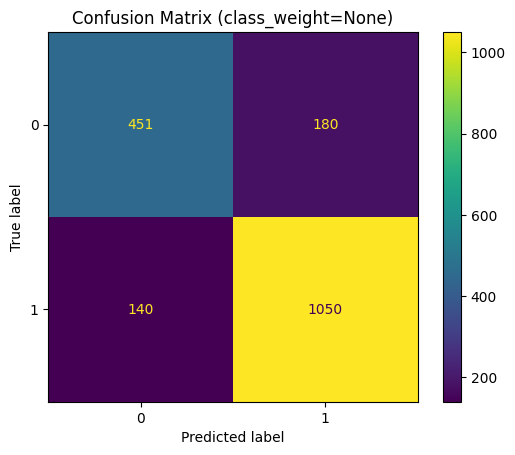


class_weight=balanced
               precision    recall  f1-score   support

           0      0.659     0.845     0.740       631
           1      0.903     0.768     0.830      1190

    accuracy                          0.795      1821
   macro avg      0.781     0.806     0.785      1821
weighted avg      0.819     0.795     0.799      1821



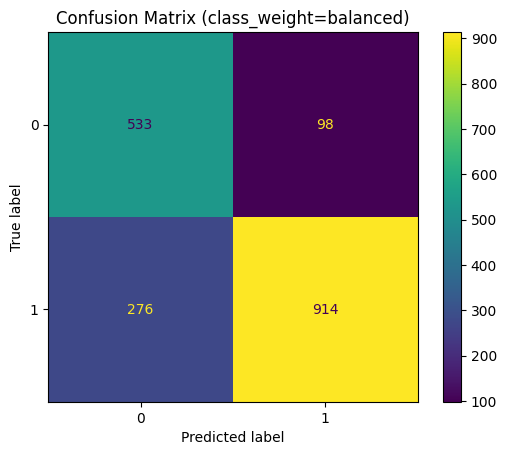

In [23]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load and quick clean
df = pd.read_csv("support2.csv").replace({'': np.nan, 'NA': np.nan, 'N/A': np.nan, '?': np.nan})
df = df.fillna(df.median(numeric_only=True)).dropna(subset=['hday'])

# Binary target
df['hday_bin'] = (df['hday'] == 1).astype(int)
X, y = df.drop(columns=['hday','hday_bin']), df['hday_bin']
X = pd.get_dummies(X, drop_first=True)

# Train/test and scale
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
Xtr_s, Xte_s = StandardScaler().fit_transform(Xtr), StandardScaler().fit(Xtr).transform(Xte)

# Logistic regression (baseline and balanced)
for w in [None, "balanced"]:
    lr = LogisticRegression(max_iter=1000, class_weight=w)
    lr.fit(Xtr_s, ytr)
    yp = lr.predict(Xte_s)
    print(f"\nclass_weight={w}\n", classification_report(yte, yp, digits=3))
    ConfusionMatrixDisplay.from_predictions(yte, yp)
    plt.title(f"Confusion Matrix (class_weight={w})"); plt.show()

## SUPPORT2 Modeling Summary

For the SUPPORT2 workflow, hospital days were converted into a classification target. The unbalanced model produced higher overall accuracy, while the balanced model improved recall for the lower-frequency class. This comparison shows the tradeoff between maximizing overall accuracy and improving minority-class detection.
